<a href="https://colab.research.google.com/github/NTU-king-james/EllipticPlusPlus/blob/OscarOu/Graph_refinement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch==2.5.0 torchvision==0.20.0 torchaudio==2.5.0 --index-url https://download.pytorch.org/whl/cu124
import os
import torch
os.environ["TORCH"] = torch.__version__
print(torch.__version__)
def format_pytorch_version(version):
  return version.split('+')[0]
TORCH_version = torch.__version__
TORCH = format_pytorch_version(TORCH_version)
def format_cuda_version(version):
  return "cu" + version.replace(".", "")
CUDA_version = torch.version.cuda
CUDA = format_cuda_version(CUDA_version)
!pip install torch-scatter -f https://pytorch-geometric.com/whl/torch-{TORCH}+{CUDA}.html
!pip install torch-sparse -f https://pytorch-geometric.com/whl/torch-{TORCH}+{CUDA}.html
!pip install torch-cluster -f https://pytorch-geometric.com/whl/torch-{TORCH}+{CUDA}.html
!pip install torch-spline-conv -f https://pytorch-geometric.com/whl/torch-{TORCH}+{CUDA}.html
!pip install torch-geometric
!pip install -r requirements.txt

Looking in indexes: https://download.pytorch.org/whl/cu124
2.5.0+cu124
Looking in links: https://pytorch-geometric.com/whl/torch-2.5.0+cu124.html
Looking in links: https://pytorch-geometric.com/whl/torch-2.5.0+cu124.html
Looking in links: https://pytorch-geometric.com/whl/torch-2.5.0+cu124.html
Looking in links: https://pytorch-geometric.com/whl/torch-2.5.0+cu124.html


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import plotly.graph_objs as go
import plotly.offline as py
import math
# from IPython.core.interactiveshell import InteractiveShell
# InteractiveShell.ast_node_interactivity = 'all'

## Fetch Dataset

This is elliptic++ dataset, the following data preprocessing are all for elliptic++. For elliptic, please do your own implementation

In [ ]:
import gdown
!gdown --fuzzy "https://drive.google.com/file/d/19q09IFhfkOOBOXvn_dKhWjILJtjCcsjc/view?usp=drive_link"
!gdown --fuzzy "https://drive.google.com/file/d/1DiBxn8TXdbJqoSw58pYUeaqO3oOKhuQO/view?usp=drive_link"
!gdown --fuzzy "https://drive.google.com/file/d/1Q2yG_CIDvfdGP-fKVPSw979EYgQukjz5/view?usp=drive_link"

Downloading...
From (original): https://drive.google.com/uc?id=19q09IFhfkOOBOXvn_dKhWjILJtjCcsjc
From (redirected): https://drive.google.com/uc?id=19q09IFhfkOOBOXvn_dKhWjILJtjCcsjc&confirm=t&uuid=f4186ea6-e546-4e40-8c44-544f6830cf92
To: /content/txs_features.csv
100% 695M/695M [00:13<00:00, 51.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=1DiBxn8TXdbJqoSw58pYUeaqO3oOKhuQO
To: /content/txs_classes.csv
100% 2.36M/2.36M [00:00<00:00, 163MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Q2yG_CIDvfdGP-fKVPSw979EYgQukjz5
To: /content/txs_edgelist.csv
100% 4.47M/4.47M [00:00<00:00, 41.4MB/s]


In [ ]:
print("\nTransaction features: \n")
df_txs_features = pd.read_csv("txs_features.csv")
df_txs_features

print("\nTransaction classes: \n")
df_txs_classes = pd.read_csv("txs_classes.csv")
df_txs_classes

print("\nTransaction-Transaction edgelist: \n")
df_txs_edgelist = pd.read_csv("txs_edgelist.csv")
df_txs_edgelist


Transaction features: 


Transaction classes: 


Transaction-Transaction edgelist: 



,txId1,txId2
0,230425980,5530458
1,232022460,232438397
2,230460314,230459870
3,230333930,230595899
4,232013274,232029206
...,...,...
234350,158365409,157930723
234351,188708874,188708879
234352,157659064,157659046
234353,87414554,106877725


## Data Preprocessing

1. Drop nodes (transactions) without augmented feature values (0.5% not de-anonymized)
2. Drop edges accordingly

In [ ]:
# 1. 把 feature DataFrame 裡含 NaN 的行丟掉
df_txs_features_droped = df_txs_features.dropna()
# 2. 取出還在的 txId（假設 index 就是 txId）
valid_tx = set(df_txs_features_droped.txId)

# 3. 篩邊表：只保留 txId1 與 txId2 都在 valid_tx 裡面的邊
df_txs_edgelist = df_txs_edgelist[
    df_txs_edgelist['txId1'].isin(valid_tx) &
    df_txs_edgelist['txId2'].isin(valid_tx)
].reset_index(drop=True)

In [ ]:
df_txs_edgelist

,txId1,txId2
0,230425980,5530458
1,232022460,232438397
2,230460314,230459870
3,230333930,230595899
4,232013274,232029206
...,...,...
233278,158365409,157930723
233279,188708874,188708879
233280,157659064,157659046
233281,87414554,106877725


3. Merge label into txs_features for later index mapping

In [ ]:
subset = df_txs_classes[['txId', 'class']]

# 2. 用 merge 把 class 欄併到 txs_features
df_txs_features_droped_merged = df_txs_features_droped.merge(
    subset,
    on='txId',     # 以 txId 當作 key
    how='left'     # 保留 txs_features 所有列，對不到的 class 欄會是 NaN
)

In [ ]:
df_txs_features_droped_merged

,txId,Time step,Local_feature_1,Local_feature_2,Local_feature_3,Local_feature_4,Local_feature_5,Local_feature_6,Local_feature_7,Local_feature_8,...,in_BTC_max,in_BTC_mean,in_BTC_median,in_BTC_total,out_BTC_min,out_BTC_max,out_BTC_mean,out_BTC_median,out_BTC_total,class
0,3321,1,-0.169615,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.160199,...,0.534072,0.534072,0.534072,0.534072,1.668990e-01,0.367074,0.266986,0.266986,0.533972,3
1,11108,1,-0.137586,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.127429,...,5.611878,5.611878,5.611878,5.611878,5.861940e-01,5.025584,2.805889,2.805889,5.611778,3
2,51816,1,-0.170103,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.160699,...,0.456608,0.456608,0.456608,0.456608,2.279902e-01,0.228518,0.228254,0.228254,0.456508,3
3,68869,1,-0.114267,-0.184668,-1.201369,0.028105,-0.043875,-0.113002,0.547008,-0.161652,...,8.000000,3.102967,1.000000,9.308900,1.229000e+00,8.079800,4.654400,4.654400,9.308800,2
4,89273,1,5.202107,-0.210553,-1.756361,-0.121970,260.090707,-0.113002,-0.061584,5.335864,...,852.164680,852.164680,852.164680,852.164680,1.300000e-07,41.264036,0.065016,0.000441,852.164680,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202799,194747812,49,0.558398,-0.198956,-0.091383,-0.121970,-0.043875,-0.113002,-0.061584,0.584665,...,115.952889,115.952889,115.952889,115.952889,1.653300e+00,114.299544,57.976422,57.976422,115.952844,3
202800,194747925,49,0.547658,-0.198956,-0.091383,-0.121970,-0.043875,-0.113002,-0.061584,0.573676,...,114.250098,114.250098,114.250098,114.250098,2.035300e-02,114.229700,57.125027,57.125027,114.250053,3
202801,194748063,49,0.543600,-0.198853,-0.091383,-0.121970,-0.043875,-0.113002,-0.061584,0.569524,...,113.606771,113.606771,113.606771,113.606771,9.257490e-01,112.680977,56.803363,56.803363,113.606726,3
202802,194748070,49,0.537760,-0.198853,-0.091383,-0.121970,-0.043875,-0.113002,-0.061584,0.563549,...,112.680977,112.680977,112.680977,112.680977,3.026970e-01,112.378235,56.340466,56.340466,112.680932,3


4. Normalize augmented features

In [ ]:
# For notmalize augmented features
from sklearn.preprocessing import MinMaxScaler

for column in df_txs_features_droped_merged.columns[-18:-1]:
    scaler = MinMaxScaler()
    df_txs_features_droped_merged[column] = scaler.fit_transform(df_txs_features_droped_merged[[column]])

In [ ]:
df_txs_features_droped_merged

,txId,Time step,Local_feature_1,Local_feature_2,Local_feature_3,Local_feature_4,Local_feature_5,Local_feature_6,Local_feature_7,Local_feature_8,...,in_BTC_max,in_BTC_mean,in_BTC_median,in_BTC_total,out_BTC_min,out_BTC_max,out_BTC_mean,out_BTC_median,out_BTC_total,class
0,3321,1,-0.169615,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.160199,...,0.000047,0.000047,0.000047,0.000047,8.301504e-05,0.000032,0.000089,8.904096e-05,0.000047,3
1,11108,1,-0.137586,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.127429,...,0.000493,0.000493,0.000493,0.000493,2.915711e-04,0.000444,0.000936,9.357923e-04,0.000493,3
2,51816,1,-0.170103,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.160699,...,0.000040,0.000040,0.000040,0.000040,1.134016e-04,0.000020,0.000076,7.612341e-05,0.000040,3
3,68869,1,-0.114267,-0.184668,-1.201369,0.028105,-0.043875,-0.113002,0.547008,-0.161652,...,0.000702,0.000272,0.000088,0.000817,6.113009e-04,0.000714,0.001552,1.552291e-03,0.000817,2
4,89273,1,5.202107,-0.210553,-1.756361,-0.121970,260.090707,-0.113002,-0.061584,5.335864,...,0.074805,0.074805,0.074805,0.074805,6.466160e-11,0.003648,0.000022,1.451405e-07,0.074805,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202799,194747812,49,0.558398,-0.198956,-0.091383,-0.121970,-0.043875,-0.113002,-0.061584,0.584665,...,0.010179,0.010179,0.010179,0.010179,8.223464e-04,0.010104,0.019336,1.933576e-02,0.010179,3
202800,194747925,49,0.547658,-0.198956,-0.091383,-0.121970,-0.043875,-0.113002,-0.061584,0.573676,...,0.010029,0.010029,0.010029,0.010029,1.012352e-05,0.010098,0.019052,1.905181e-02,0.010029,3
202801,194748063,49,0.543600,-0.198853,-0.091383,-0.121970,-0.043875,-0.113002,-0.061584,0.569524,...,0.009973,0.009973,0.009973,0.009973,4.604647e-04,0.009961,0.018945,1.894453e-02,0.009973,3
202802,194748070,49,0.537760,-0.198853,-0.091383,-0.121970,-0.043875,-0.113002,-0.061584,0.563549,...,0.009891,0.009891,0.009891,0.009891,1.505606e-04,0.009935,0.018790,1.879015e-02,0.009891,3


5. Set `txId` as the index for the processed DataFrame
6. Updates the index of the Dataframe with ```id_map```
7. Constructs `edge_index`

In [ ]:
import torch

df_txs_features_processed = df_txs_features_droped_merged.set_index('txId')

ids_from_src      = df_txs_edgelist['txId1']
ids_from_dst      = df_txs_edgelist['txId2']
all_ids = pd.unique(pd.concat([ids_from_src, ids_from_dst]))
id_map  = {orig_id: idx for idx, orig_id in enumerate(all_ids)}

df_txs_features_processed.index = df_txs_features_processed.index.map(id_map)

src = df_txs_edgelist['txId1'].map(id_map).values
dst = df_txs_edgelist['txId2'].map(id_map).values
edge_index = torch.tensor([src, dst], dtype=torch.long)
print(edge_index)

tensor([[     0,      1,      2,  ..., 165797, 163914, 164709],
        [  5554,    532,   1872,  ..., 202476, 202338, 164324]])


8. Extract labels and transform `licit` & `unknown`
9. Extract time steps and create mask

In [ ]:
y = df_txs_features_processed['class'].copy()
y[y == 2] = 0   # licit
y[y == 3] = 2   # unknown


time_steps = df_txs_features_processed['Time step']

train_mask, test_mask = time_steps <= 34, time_steps > 34
train_mask = torch.tensor(train_mask.to_numpy(), dtype=torch.bool)
test_mask = torch.tensor(test_mask.to_numpy(), dtype=torch.bool)

time_steps = torch.tensor(time_steps.to_numpy(), dtype=torch.int64)

In [ ]:
y

,class
txId,
166019.0,2
2324.0,2
6001.0,2
6497.0,0
66.0,0
...,...
165019.0,2
165343.0,2
164927.0,2


10. Drop label & time step

In [ ]:
df_txs_features_final = df_txs_features_processed.drop(columns=['class', 'Time step'])

11. Create raw graph (PyTorch Geometric Data)

In [ ]:
from torch_geometric.data import Data

x = torch.tensor(df_txs_features_final.values, dtype=torch.float)
data = Data(x=x, edge_index=edge_index, y=y, train_mask=train_mask, test_mask=test_mask, node_time=time_steps)
data.y = torch.from_numpy(data.y.to_numpy().astype(int)).long()

## (iii) Temporal Graph Dataset
This dataset contain all sub-graphs from 1 ~ 49, with each sampled negative edges separately, note that currently sub-graph start from 42 is `None` due to no edge issue

In [ ]:
import torch
import random
from torch_geometric.data import Data, InMemoryDataset
from torch_geometric.transforms import RandomLinkSplit

class PerTimestepEdgeLabelDataset(InMemoryDataset):
    def __init__(self, data: Data, neg_sampling_ratio=1.0):
        super().__init__("/tmp")
        self.data_list = []

        for t in torch.unique(data.node_time):

            # # sub-graph from time step 42 has no edges
            # if t >= 42:
            #     break

            # print(f"t = {t}")
            subgraph_t = self.build_subgraph(data, t)
            # print(f"sub-graph{t}: {subgraph_t}")
            train_data_t = self.random_split(subgraph_t, neg_sampling_ratio=neg_sampling_ratio)

            self.data_list.append(train_data_t)

    def build_subgraph(self, data, time_step):

        node_mask = data.node_time == time_step
        # no nodes at this time step
        if node_mask.sum() == 0:
            return None

        src, dst = data.edge_index
        edge_mask = node_mask[src] & node_mask[dst]
        edge_index_t = data.edge_index[:, edge_mask]
        node_indices = node_mask.nonzero(as_tuple=True)[0]

        # keep x, y whose time step = time_step
        x_t, y_t = data.x[node_indices], data.y[node_indices]
        node_time_t = data.node_time[node_indices]

        # 建圖時重新編號節點 (Optional: for cleaner subgraph)
        index_map = torch.full((data.num_nodes,), -1, dtype=torch.long)
        index_map[node_indices] = torch.arange(node_indices.size(0))
        edge_index_t = index_map[edge_index_t]

        return Data(
            x=x_t,
            y=y_t,
            edge_index=edge_index_t,
            num_nodes=node_indices.size(0),
            node_time=node_time_t,
        )


    def random_split(self, data, neg_sampling_ratio=1.0):
        splitter = RandomLinkSplit(
            is_undirected=False,
            split_labels=False,
            add_negative_train_samples=True,
            neg_sampling_ratio=neg_sampling_ratio,
            num_val=0,
            num_test=0,
        )
        try:
            train_data_t, _, _ = splitter(data)
            # print(train_data_t)
            assert isinstance(train_data_t, Data)
            return train_data_t
        except Exception as e:
            print(f"Skipping timestep {data.node_time[0]} due to error: {e}")
            return None


    def hard_negative_split(self, data, neg_sampling_ratio=1, k_hop_neighbors=1):
        from torch_geometric.utils import k_hop_subgraph

        edge_index = data.edge_index
        node_time = data.node_time
        pos_edge_index = edge_index
        existing_edges = set((u.item(), v.item()) for u, v in edge_index.t())

        neg_edges = []
        for u in range(data.num_nodes):
            if len(neg_edges) >= neg_sampling_ratio * edge_index.size(1):
                break
            # Get k-hop neighbors of u
            subset, _, _, _ = k_hop_subgraph(u, num_hops=k_hop_neighbors, edge_index=edge_index, relabel_nodes=False)
            neighbors = set(subset.tolist())
            candidates = set(range(data.num_nodes)) - neighbors - {u}
            if len(candidates) == 0:
                continue
            v = random.choice(list(candidates))
            if (u, v) not in existing_edges and (v, u) not in existing_edges:
                neg_edges.append((u, v))

        if len(neg_edges) == 0:
            return None  # skip empty

        neg_edge_index = torch.tensor(neg_edges, dtype=torch.long).t()
        pos_edge_label = torch.ones(pos_edge_index.size(1), dtype=torch.float)
        neg_edge_label = torch.zeros(neg_edge_index.size(1), dtype=torch.float)

        edge_label_index = torch.cat([pos_edge_index, neg_edge_index], dim=1)
        edge_label = torch.cat([pos_edge_label, neg_edge_label], dim=0)

        return Data(
            x=data.x,
            edge_index=data.edge_index,
            edge_label_index=edge_label_index,
            edge_label=edge_label,
            node_time=data.node_time,
        )


    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        return self.data_list[idx]

In [ ]:
from torch_geometric.loader import DataLoader

dataset = PerTimestepEdgeLabelDataset(data, neg_sampling_ratio=1.0)
loader = DataLoader(dataset, batch_size=1, shuffle=False)

Skipping timestep 42 due to error: Insufficient number of edges for training
Skipping timestep 43 due to error: Insufficient number of edges for training
Skipping timestep 44 due to error: Insufficient number of edges for training
Skipping timestep 45 due to error: Insufficient number of edges for training
Skipping timestep 46 due to error: Insufficient number of edges for training
Skipping timestep 47 due to error: Insufficient number of edges for training
Skipping timestep 48 due to error: Insufficient number of edges for training
Skipping timestep 49 due to error: Insufficient number of edges for training


In [ ]:
import torch
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def visualize_tsne_binary(model, data, stage='before'):
    model.eval()
    with torch.no_grad():
        z = model(data.x, data.edge_index)

    # 🟢 Filter nodes with class 0 or 1
    mask = (data.y == 0) | (data.y == 1)
    if mask.sum() == 0:
        raise ValueError("No nodes with label 0 or 1 found.")

    z_filtered = z[mask]
    y_filtered = data.y[mask]

    # 🔵 Convert to CPU numpy arrays
    z_np = z_filtered.detach().cpu().numpy()
    y_np = y_filtered.detach().cpu().numpy()

    # 🟥 Map y=0 → green, y=1 → red
    color_map = np.where(y_np == 0, 'green', 'red')

    # 🔵 t-SNE projection
    tsne = TSNE(n_components=2, random_state=42)
    z_2d = tsne.fit_transform(z_np)

    # 🔴 Plot
    plt.figure(figsize=(8, 6))
    for label, color in zip([0, 1], ['green', 'red']):
        idx = y_np == label
        plt.scatter(z_2d[idx, 0], z_2d[idx, 1], c=color, label=f"Class {label}", s=10)

    plt.legend()
    plt.title(f"t-SNE of Embeddings for Class 0 (green) and 1 (red) ({stage} training)")
    plt.show()

### Test on subgraph 1 (tiem step = 1)

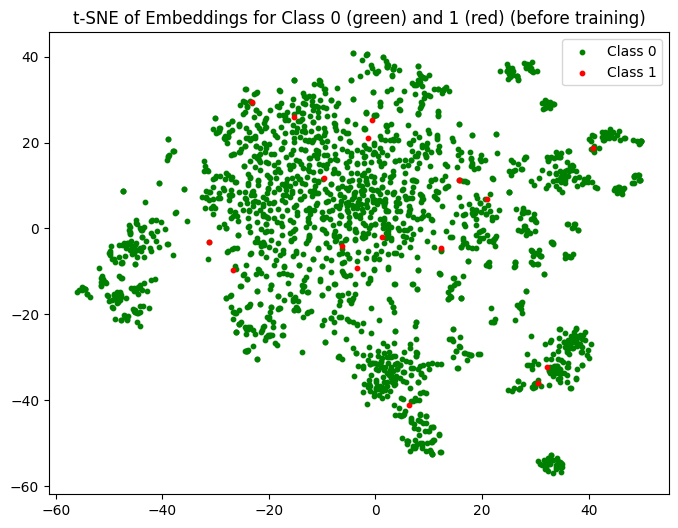

Epoch 001 | Loss: 0.8132 | AUC: 0.6541 | F1: 0.6667 | Precision: 0.5000 | Recall: 1.0000
Epoch 002 | Loss: 0.8131 | AUC: 0.6625 | F1: 0.6667 | Precision: 0.5000 | Recall: 1.0000
Epoch 003 | Loss: 0.8130 | AUC: 0.6714 | F1: 0.6667 | Precision: 0.5000 | Recall: 1.0000
Epoch 004 | Loss: 0.8128 | AUC: 0.6808 | F1: 0.6667 | Precision: 0.5000 | Recall: 1.0000
Epoch 005 | Loss: 0.8127 | AUC: 0.6896 | F1: 0.6667 | Precision: 0.5000 | Recall: 1.0000
Epoch 006 | Loss: 0.8125 | AUC: 0.6968 | F1: 0.6667 | Precision: 0.5000 | Recall: 1.0000
Epoch 007 | Loss: 0.8122 | AUC: 0.7053 | F1: 0.6667 | Precision: 0.5000 | Recall: 1.0000
Epoch 008 | Loss: 0.8118 | AUC: 0.7134 | F1: 0.6667 | Precision: 0.5000 | Recall: 1.0000
Epoch 009 | Loss: 0.8113 | AUC: 0.7208 | F1: 0.6667 | Precision: 0.5000 | Recall: 1.0000
Epoch 010 | Loss: 0.8107 | AUC: 0.7296 | F1: 0.6667 | Precision: 0.5000 | Recall: 1.0000
Epoch 011 | Loss: 0.8099 | AUC: 0.7373 | F1: 0.6667 | Precision: 0.5000 | Recall: 1.0000
Epoch 012 | Loss: 0.8

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch_geometric.nn import GCNConv, GAE
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score

# Define Encoder
class GAEEncoder(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        return self.conv2(x, edge_index)

# Model & Optimizer
in_feats = data.num_node_features
hidden_dim = 256
out_dim = 128
encoder = GAEEncoder(in_feats, hidden_dim, out_dim)
gae_model = GAE(encoder)
optimizer = torch.optim.Adam(gae_model.parameters(), lr=0.0001)
bce_loss = torch.nn.BCEWithLogitsLoss()

# Get training subgraph (time step 1)
train_batch = dataset[0]

visualize_tsne_binary(gae_model, train_batch, stage='before')

def train_single_graph(train_batch):

    loss_list, auc_list, f1_list, precision_list, recall_list = [], [], [], [], []
    epochs = 300

    for epoch in range(1, epochs + 1):
        _ = gae_model.train()
        optimizer.zero_grad()

        # Forward
        z = gae_model.encode(train_batch.x.squeeze(0), train_batch.edge_index.squeeze(0))
        edge_label_index = train_batch.edge_label_index.squeeze(0)
        edge_label = train_batch.edge_label.squeeze(0).float()
        logits = gae_model.decode(z, edge_label_index).view(-1)

        # Loss
        loss = bce_loss(logits, edge_label)
        loss.backward()
        optimizer.step()

        # Evaluation
        with torch.no_grad():
            probs = torch.sigmoid(logits).cpu()
            # print(f"probs: {probs}")
            # print(f"edge_label_index: {edge_label_index}")
            preds = (probs > 0.5).float()
            labels = edge_label.cpu()

            auc = roc_auc_score(labels, probs)
            f1 = f1_score(labels, preds)
            precision = precision_score(labels, preds)
            recall = recall_score(labels, preds)

            # Save metrics
            loss_list.append(loss.item())
            auc_list.append(auc)
            f1_list.append(f1)
            precision_list.append(precision)
            recall_list.append(recall)

            print(f"Epoch {epoch:03d} | Loss: {loss.item():.4f} | AUC: {auc:.4f} | F1: {f1:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f}")

    return loss_list, auc_list, f1_list, precision_list, recall_list

loss_list, auc_list, f1_list, precision_list, recall_list = train_single_graph(train_batch)

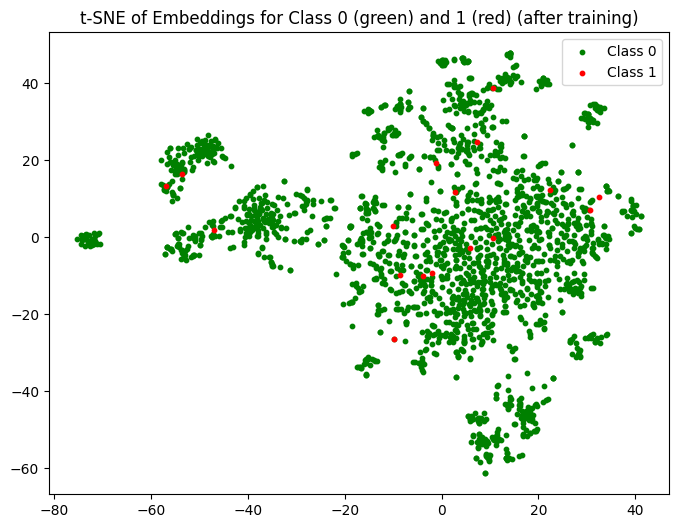

In [ ]:
visualize_tsne_binary(gae_model, train_batch, stage='after')

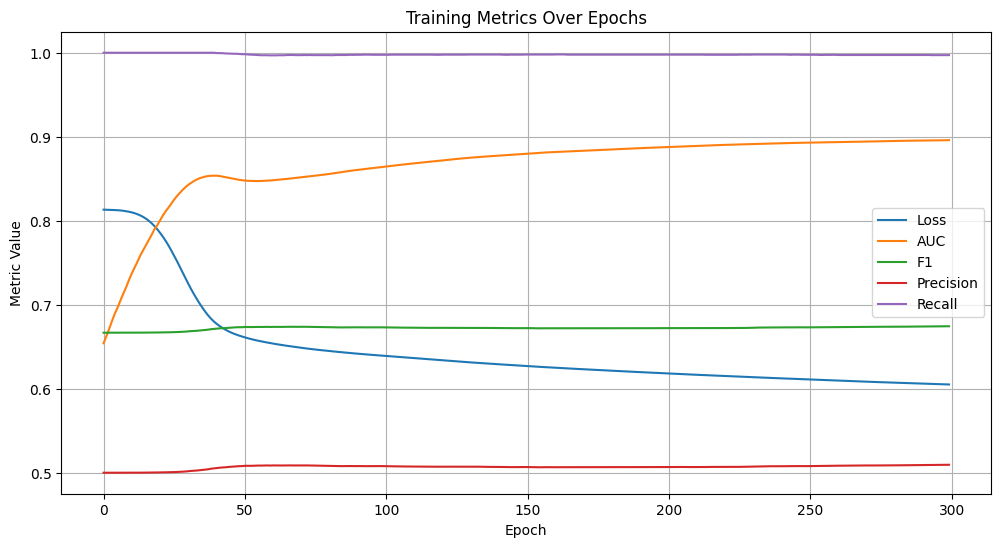

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(loss_list, label='Loss')
plt.plot(auc_list, label='AUC')
plt.plot(f1_list, label='F1')
plt.plot(precision_list, label='Precision')
plt.plot(recall_list, label='Recall')
plt.xlabel("Epoch")
plt.ylabel("Metric Value")
plt.title("Training Metrics Over Epochs")
plt.legend()
plt.grid(True)
plt.show()

Min score: 0.5000, Max score: 0.7311
Fraction > 0.5: 0.9785


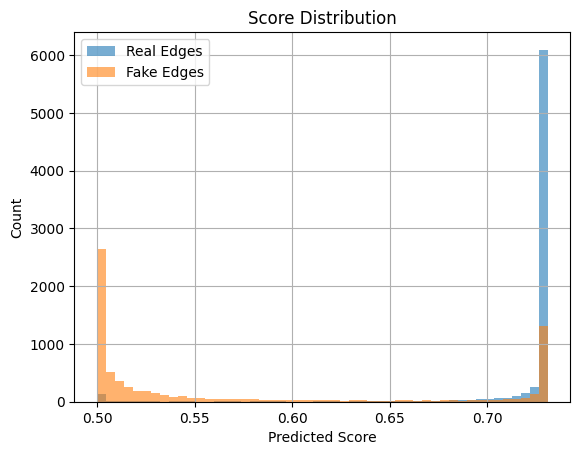

In [ ]:
with torch.no_grad():
    _ = gae_model.eval()
    z = gae_model.encode(train_batch.x.squeeze(0), train_batch.edge_index.squeeze(0))
    logits = gae_model.decode(z, train_batch.edge_label_index.squeeze(0)).view(-1)
    probs = torch.sigmoid(logits).cpu()

    print(f"Min score: {probs.min().item():.4f}, Max score: {probs.max().item():.4f}")
    print(f"Fraction > 0.5: {(probs > 0.5).float().mean().item():.4f}")
    labels = train_batch.edge_label.squeeze(0).cpu()

    real_scores = probs[labels == 1]
    fake_scores = probs[labels == 0]

    plt.hist(real_scores.numpy(), bins=50, alpha=0.6, label='Real Edges')
    plt.hist(fake_scores.numpy(), bins=50, alpha=0.6, label='Fake Edges')
    plt.xlabel("Predicted Score")
    plt.ylabel("Count")
    plt.title("Score Distribution")
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
import torch

def find_high_score_fake_edges(train_batch, probs, labels, k=20, threshold=0.95):
    """
    找出分數最高的 fake edges（模型錯誤認為有邊），並做篩選

    參數:
        train_batch: 包含 edge_label_index 和 edge_label 的圖 batch
        probs: 經過 sigmoid 的預測分數 (1D tensor)
        labels: 實際邊的 label (1D tensor)，1 表 real edge, 0 表 fake edge
        k: 要挑出前幾名高分 fake edges
        threshold: 最低分數門檻，超過才會納入 refined edges

    回傳:
        refined_edges: shape [2, n] 的 tensor，代表 pseudo-positive edge 的節點對
        topk_fake_edges: shape [2, k] 的 tensor，所有 top-k fake edge 的節點對（未過濾）
        topk_scores: shape [k] 的 tensor，對應分數
    """
    # Step 1: 找出所有 fake edges 的 index
    fake_indices = (labels == 0).nonzero(as_tuple=True)[0]

    # Step 2: 在 fake_scores 裡找出 top-k 高分邊
    fake_scores = probs[fake_indices]
    topk_scores, topk_idx_in_fake = torch.topk(fake_scores, k)

    # Step 3: 對應回原 edge_label_index 的位置
    topk_fake_global_idx = fake_indices[topk_idx_in_fake]
    topk_fake_edges = train_batch.edge_label_index[:, topk_fake_global_idx]

    # Step 4: 根據 threshold 過濾
    refine_mask = topk_scores >= threshold
    refined_edges = topk_fake_edges[:, refine_mask]

    return refined_edges, topk_fake_edges, topk_scores


# 把 refined_edges 加入原 edge_index
# new_edge_index = torch.cat([train_batch.edge_index.squeeze(0), refined_edges], dim=1)


In [ ]:
refined_edges, topk_fake_edges, topk_scores = find_high_score_fake_edges(
    train_batch, probs, labels, k=2000, threshold=probs.max()
)

print(len(refined_edges[0]))
print(len(topk_fake_edges[0]))
print(topk_scores)

361
2000
tensor([0.7311, 0.7311, 0.7311,  ..., 0.6358, 0.6356, 0.6354])


In [ ]:
# 把 refined_edges 加入原 edge_index
new_edge_index = torch.cat([train_batch.edge_index.squeeze(0), refined_edges], dim=1)
print(len(train_batch.edge_index.squeeze(0)[0]))
print(len(new_edge_index[0]))


7317
7678


In [ ]:
new_edge_index = torch.empty((2, 0), dtype=torch.long)
new_edge_index_all = torch.empty((2, 0), dtype=torch.long)

for i in range(41):
  print("Now training time step ", i)
  train_batch = dataset[i]
  loss_list, auc_list, f1_list, precision_list, recall_list = train_single_graph(train_batch)
  with torch.no_grad():
    _ = gae_model.eval()
    z = gae_model.encode(train_batch.x.squeeze(0), train_batch.edge_index.squeeze(0))
    logits = gae_model.decode(z, train_batch.edge_label_index.squeeze(0)).view(-1)
    probs = torch.sigmoid(logits).cpu()

    print(f"Min score: {probs.min().item():.4f}, Max score: {probs.max().item():.4f}")
    print(f"Fraction > 0.5: {(probs > 0.5).float().mean().item():.4f}")
    labels = train_batch.edge_label.squeeze(0).cpu()

    real_scores = probs[labels == 1]
    fake_scores = probs[labels == 0]
    num_fake_edges = (labels == 0).sum().item()
    k = (num_fake_edges // 2)
    refined_edges, topk_fake_edges, topk_scores = find_high_score_fake_edges(
    train_batch, probs, labels, k, threshold=probs.max())
    new_edge_index = torch.cat([train_batch.edge_index.squeeze(0), refined_edges], dim=1)
    new_edge_index_all = torch.cat([new_edge_index_all, new_edge_index], dim=1)

串流輸出內容已截斷至最後 5000 行。
Epoch 151 | Loss: 0.6019 | AUC: 0.8517 | F1: 0.7811 | Precision: 0.6457 | Recall: 0.9884
Epoch 152 | Loss: 0.6018 | AUC: 0.8516 | F1: 0.7808 | Precision: 0.6453 | Recall: 0.9884
Epoch 153 | Loss: 0.6016 | AUC: 0.8515 | F1: 0.7808 | Precision: 0.6453 | Recall: 0.9884
Epoch 154 | Loss: 0.6013 | AUC: 0.8512 | F1: 0.7808 | Precision: 0.6453 | Recall: 0.9884
Epoch 155 | Loss: 0.6011 | AUC: 0.8512 | F1: 0.7805 | Precision: 0.6449 | Recall: 0.9884
Epoch 156 | Loss: 0.6009 | AUC: 0.8514 | F1: 0.7810 | Precision: 0.6451 | Recall: 0.9894
Epoch 157 | Loss: 0.6006 | AUC: 0.8527 | F1: 0.7813 | Precision: 0.6455 | Recall: 0.9894
Epoch 158 | Loss: 0.6003 | AUC: 0.8527 | F1: 0.7807 | Precision: 0.6447 | Recall: 0.9894
Epoch 159 | Loss: 0.6000 | AUC: 0.8531 | F1: 0.7809 | Precision: 0.6445 | Recall: 0.9904
Epoch 160 | Loss: 0.5999 | AUC: 0.8535 | F1: 0.7817 | Precision: 0.6457 | Recall: 0.9904
Epoch 161 | Loss: 0.5998 | AUC: 0.8542 | F1: 0.7820 | Precision: 0.6461 | Recall: 0.9904


In [ ]:
from torch_geometric.data import Data

x = torch.tensor(df_txs_features_final.values, dtype=torch.float)
data = Data(x=x, edge_index=new_edge_index_all, y=y, train_mask=train_mask, test_mask=test_mask, node_time=time_steps)
data.y = torch.from_numpy(data.y.to_numpy().astype(int)).long()

## Train on all sub-graph (1 ~ 41 only)

300 epochs for each sub-graph

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch_geometric.nn import GCNConv, GAE
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score

# Define Encoder
class GAEEncoder(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        return self.conv2(x, edge_index)

# Model & Optimizer
in_feats = data.num_node_features
hidden_dim = 128
out_dim = 64
encoder = GAEEncoder(in_feats, hidden_dim, out_dim)
gae_model = GAE(encoder)
optimizer = torch.optim.Adam(gae_model.parameters(), lr=0.0001)
bce_loss = torch.nn.BCEWithLogitsLoss()

def train_single_graph(train_batch):

    loss_list, auc_list, f1_list, precision_list, recall_list = [], [], [], [], []
    epochs = 300

    for epoch in range(1, epochs + 1):
        _ = gae_model.train()
        optimizer.zero_grad()

        # Forward
        z = gae_model.encode(train_batch.x.squeeze(0), train_batch.edge_index.squeeze(0))
        edge_label_index = train_batch.edge_label_index.squeeze(0)
        edge_label = train_batch.edge_label.squeeze(0).float()
        logits = gae_model.decode(z, edge_label_index).view(-1)

        # Loss
        loss = bce_loss(logits, edge_label)
        loss.backward()
        optimizer.step()

        # Evaluation
        with torch.no_grad():
            probs = torch.sigmoid(logits).cpu()
            preds = (probs > 0.5).float()
            labels = edge_label.cpu()

            auc = roc_auc_score(labels, probs)
            f1 = f1_score(labels, preds)
            precision = precision_score(labels, preds)
            recall = recall_score(labels, preds)

            # Save metrics
            loss_list.append(loss.item())
            auc_list.append(auc)
            f1_list.append(f1)
            precision_list.append(precision)
            recall_list.append(recall)

            # print(f"probs: {probs}")
            # print(f"edge_label_index: {edge_label_index}")
            print(f"Epoch {epoch:03d} | Loss: {loss.item():.4f} | AUC: {auc:.4f} | F1: {f1:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f}")

    return loss_list, auc_list, f1_list, precision_list, recall_list

# print(train_batch)
for t, train_batch in enumerate(dataset):
    if t > 40: break
    print(f"t={t}, train_batch={train_batch}")
    loss_list, auc_list, f1_list, precision_list, recall_list = train_single_graph(train_batch)

串流輸出內容已截斷至最後 5000 行。
Epoch 117 | Loss: 0.6080 | AUC: 0.8462 | F1: 0.7607 | Precision: 0.6186 | Recall: 0.9875
Epoch 118 | Loss: 0.6080 | AUC: 0.8462 | F1: 0.7607 | Precision: 0.6186 | Recall: 0.9875
Epoch 119 | Loss: 0.6079 | AUC: 0.8462 | F1: 0.7610 | Precision: 0.6190 | Recall: 0.9875
Epoch 120 | Loss: 0.6078 | AUC: 0.8462 | F1: 0.7612 | Precision: 0.6193 | Recall: 0.9875
Epoch 121 | Loss: 0.6076 | AUC: 0.8458 | F1: 0.7612 | Precision: 0.6193 | Recall: 0.9875
Epoch 122 | Loss: 0.6075 | AUC: 0.8458 | F1: 0.7612 | Precision: 0.6193 | Recall: 0.9875
Epoch 123 | Loss: 0.6074 | AUC: 0.8452 | F1: 0.7612 | Precision: 0.6193 | Recall: 0.9875
Epoch 124 | Loss: 0.6074 | AUC: 0.8457 | F1: 0.7610 | Precision: 0.6190 | Recall: 0.9875
Epoch 125 | Loss: 0.6074 | AUC: 0.8457 | F1: 0.7612 | Precision: 0.6193 | Recall: 0.9875
Epoch 126 | Loss: 0.6074 | AUC: 0.8462 | F1: 0.7615 | Precision: 0.6197 | Recall: 0.9875
Epoch 127 | Loss: 0.6074 | AUC: 0.8462 | F1: 0.7618 | Precision: 0.6201 | Recall: 0.9875


In [ ]:
train_mask = (data.y != 2) & data.train_mask
test_mask  = (data.y != 2) & data.test_mask

y_train = data.y[train_mask].cpu().numpy()
y_test  = data.y[test_mask].cpu().numpy()

### RF classifier with only GNE (GAE Node Embedding)

In [ ]:
import torch
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


# get node embeddings
gae_model.eval()  # Important: turn off dropout etc. during inference
with torch.no_grad():
    z = gae_model.encode(data.x, data.edge_index)  # z is of shape [num_nodes, out_dim]


X_train = z[train_mask].cpu().numpy()
X_test  = z[test_mask].cpu().numpy()

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='macro')
rec  = recall_score(y_test, y_pred, average='macro')
f1   = f1_score(y_test, y_pred, average='macro')

print(f"Random Forest - Acc: {acc:.4f}, Prec: {prec:.4f}, Rec: {rec:.4f}, F1: {f1:.4f}")

Random Forest - Acc: 0.9513, Prec: 0.9452, Rec: 0.6411, F1: 0.7050


### RF classifier with GNE + AF

In [ ]:
z_augmented = torch.cat([data.x, z], dim=1)  # shape: [202804, 310]

X_train_aug = z_augmented[train_mask].cpu().numpy()
X_test_aug  = z_augmented[test_mask].cpu().numpy()

rf_aug = RandomForestClassifier(n_estimators=100, random_state=42)
rf_aug.fit(X_train_aug, y_train)

y_pred_aug = rf_aug.predict(X_test_aug)

acc  = accuracy_score(y_test, y_pred_aug)
prec = precision_score(y_test, y_pred_aug, average='macro')
rec  = recall_score(y_test, y_pred_aug, average='macro')
f1   = f1_score(y_test, y_pred_aug, average='macro')

print(f"Random Forest - Acc: {acc:.4f}, Prec: {prec:.4f}, Rec: {rec:.4f}, F1: {f1:.4f}")

Random Forest - Acc: 0.9791, Prec: 0.9660, Rec: 0.8597, F1: 0.9050


### RF Classifier with only AF

In [ ]:
import torch
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

X_train_af = data.x[train_mask].cpu().numpy()
X_test_af  = data.x[test_mask].cpu().numpy()

rf_af = RandomForestClassifier(n_estimators=50, random_state=42)
rf_af.fit(X_train_af, y_train)

y_pred_af = rf_af.predict(X_test_af)

acc  = accuracy_score(y_test, y_pred_af)
prec = precision_score(y_test, y_pred_af, average='macro')
rec  = recall_score(y_test, y_pred_af, average='macro')
f1   = f1_score(y_test, y_pred_af, average='macro')

print(f"Random Forest - Acc: {acc:.4f}, Prec: {prec:.4f}, Rec: {rec:.4f}, F1: {f1:.4f}")

Random Forest - Acc: 0.9795, Prec: 0.9700, Rec: 0.8595, F1: 0.9063


## GAE, GCN

In [ ]:
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, GAE
from sklearn.metrics import f1_score, precision_score, recall_score

class NodeClassifier(torch.nn.Module):
    def __init__(self, in_channels, num_classes):
        super().__init__()
        self.lin = torch.nn.Linear(in_channels, num_classes)
    def forward(self, z):
        return self.lin(z)

in_feats    = data.num_node_features
hidden_dim  = 256
out_dim     = 128
num_classes = int(data.y[data.y != 2].max() + 1)

classifier = NodeClassifier(out_dim, num_classes)

optimizer = torch.optim.Adam(
    list(classifier.parameters()),
    lr=0.001
)
ce_loss  = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(classifier.parameters(), lr=0.01)
loss_fn = torch.nn.CrossEntropyLoss()

# get node embeddings
gae_model.eval()  # Important: turn off dropout etc. during inference
with torch.no_grad():
    z = gae_model.encode(data.x, data.edge_index)  # z is of shape [num_nodes, out_dim]

# training loop
for epoch in range(300):
    classifier.train()
    optimizer.zero_grad()
    out = classifier(z)  # shape [num_nodes, num_classes]
    train_mask = (data.y != 2) & data.train_mask
    loss = loss_fn(out[train_mask], data.y[train_mask])
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

classifier.eval()
with torch.no_grad():
    out = classifier(z)
    pred = out.argmax(dim=1)
    test_mask = (data.y != 2) & data.test_mask
    acc = (pred[test_mask] == data.y[test_mask]).float().mean()
    prec = precision_score(data.y[test_mask], pred[test_mask], average='macro')
    rec  = recall_score(data.y[test_mask], pred[test_mask], average='macro')
    f1   = f1_score(data.y[test_mask], pred[test_mask], average='macro')
    print(f"Test Acc={acc:.4f} | "
            f"Precision={prec:.4f} | "
            f"Recall={rec:.4f} | "
            f"F1={f1:.4f}")

